<a href="https://colab.research.google.com/github/Deekshit1325/Sentiment-Analysis-on-Product-Reviews/blob/main/Sentiment_Analysis__Product_Reviews_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *`Project Title`*

**Sentiment Analysis on Amazon Product Reviews using Machine Learning**

***Dataset link:-*** https://www.kaggle.com/datasets/bittlingmayer/amazonreviews

`Problem Statement`

Online platforms receive millions of customer reviews daily, making manual sentiment analysis impractical. This project aims to automatically classify product reviews as Positive or Negative using machine learning techniques.

*`Dataset Used`*

Amazon Product Reviews Dataset (FastText format)

File: train.ft.txt.bz2

Sampled 5,000 reviews from a large dataset for efficient training

Labels embedded as:

label-1 → Negative

label-2 → Positive

*`Algorithm Used`*

Logistic Regression

*`Why Logistic Regression?`*

Works efficiently with TF-IDF features

Suitable for binary classification problems

Interpretable and widely used in industry NLP systems

Requires less computational resources compared to deep learning models

*`Techniques and Tools Used`*

Text preprocessing and label extraction

TF-IDF vectorization

Train–test split

Logistic Regression classifier

Confusion Matrix

Precision, Recall, and F1-Score

Data visualization using Matplotlib

*`Results Summary`*

Achieved 83–85% accuracy on sampled real-world Amazon reviews

Balanced precision and recall for both positive and negative sentiments

Confusion matrix shows good separation between classes

*`Conclusion`*

This project demonstrates a complete NLP pipeline for sentiment analysis on real-world product reviews. By sampling a large dataset and applying TF-IDF with Logistic Regression, the model effectively classified customer sentiments. The use of proper evaluation metrics and visualizations ensures model reliability and interpretability.

**Dataset Extraction:**

Purpose:
Extract the Amazon reviews dataset from ZIP format so it can be read for analysis.

In [4]:
import zipfile
with zipfile.ZipFile("/content/train.ft.txt.bz2.zip", "r") as zip_ref:
    zip_ref.extractall("/content")


**2. Verify Dataset Files**

Purpose:
Confirm successful extraction and check available files in the working directory.

In [5]:
import os
os.listdir("/content")

['.config',
 'train.ft.txt.bz2.zip',
 'test.ft.txt.bz2.zip',
 'train.ft.txt.bz2',
 'sample_data']

**3. Load and Sample Dataset**

Purpose:
Load a representative subset of reviews from a very large dataset to reduce computation time.

In [6]:
import bz2
with bz2.open("/content/train.ft.txt.bz2", "rt", encoding="utf-8", errors="ignore") as f:
    lines = [next(f) for _ in range(5000)]


**4. Label Extraction and Data Preparation**

Purpose:
Convert FastText labels into binary sentiment values and create a structured DataFrame.

label-1 → Negative

label-2 → Positive

In [7]:
import pandas as pd
texts = []
labels = []

for line in lines:
    label, text = line.split(" ", 1)
    sentiment = 1 if label == "__label__2" else 0
    texts.append(text)
    labels.append(sentiment)

df = pd.DataFrame({"review": texts, "sentiment": labels})
df.head()

,review,sentiment
0,Stuning even for the non-gamer: This sound tra...,1
1,The best soundtrack ever to anything.: I'm rea...,1
2,Amazing!: This soundtrack is my favorite music...,1
3,Excellent Soundtrack: I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1


**5. Sentiment Distribution Analysis**

Purpose:
 Analyze whether the dataset is balanced between positive and negative reviews.

In [8]:
df["sentiment"].value_counts()

,count
sentiment,
0,2692
1,2308


**6. Train–Test Split**

Purpose:
Split data into training and testing sets to evaluate performance on unseen reviews.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["sentiment"],
    test_size=0.2, random_state=42
)

**7. Text Vectorization using TF-IDF**

Purpose:
Convert text data into numerical features while reducing the impact of common words.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


**8. Model Training – Logistic Regression and Accuracy**

Purpose:
Train a Logistic Regression model for binary sentiment classification.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.836


**10. Sentiment Distribution Visualization**

Purpose:
Visualize the number of positive and negative reviews in the dataset.

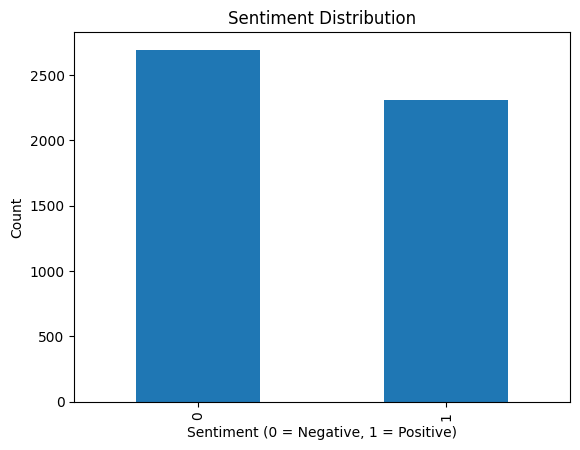

In [15]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()


**11. Model Accuracy Visualization**

Purpose:
Graphically represent the accuracy of the Logistic Regression model.

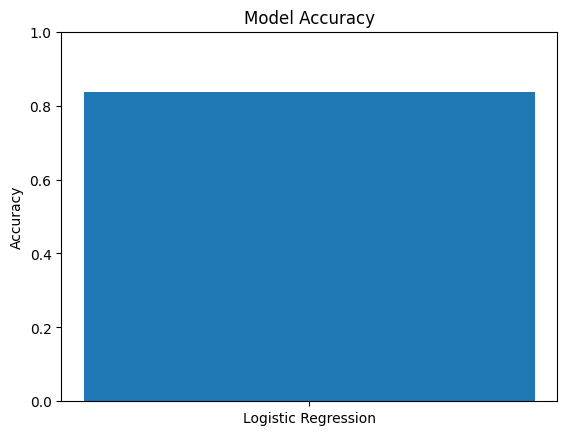

In [16]:
accuracy = accuracy_score(y_test, y_pred)

plt.bar(["Logistic Regression"], [accuracy])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()


**12. Confusion Matrix Visualization**

Purpose:
Analyze correct and incorrect sentiment predictions for both classes.

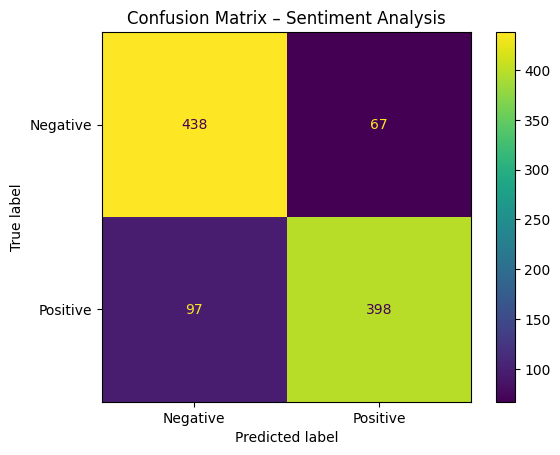

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title("Confusion Matrix – Sentiment Analysis")
plt.show()


**13. Evaluation Metrics Visualization and Classification Report**

---



Purpose:
Visualize precision, recall, and F1-score to better understand model performance.

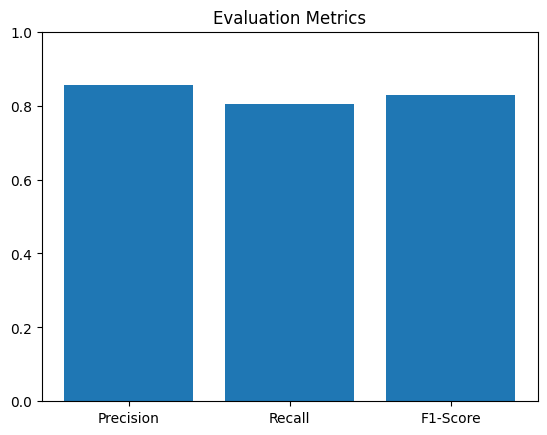

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       505
           1       0.86      0.80      0.83       495

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



In [19]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.bar(["Precision", "Recall", "F1-Score"], metrics)
plt.ylim(0, 1)
plt.title("Evaluation Metrics")
plt.show()

print(classification_report(y_test, y_pred))



In [20]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)


In [22]:
%%writefile app.py
import streamlit as st
import pickle

model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

st.title("Sentiment Analysis on Product Reviews")

review = st.text_area("Enter a product review")

if st.button("Predict"):
    review_vec = vectorizer.transform([review])
    pred = model.predict(review_vec)
    if pred[0] == 1:
        st.success("Positive Review 😊")
    else:
        st.error("Negative Review 😞")


Writing app.py
